<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
text-align:center;
font-size:28px;
">
Ejercicios Astroquery (4)
</h2>

</div>

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Ejercicio 1
</h3>

<p>
Identifique al menos tres de las líneas espectrales observadas en el espectro de NGC 5406.
</p>

<p>
Utilizando esa información, ¿cuál es el corrimiento al rojo (redshift) de esta galaxia?
</p>

</div>

In [23]:
from astroquery.simbad import Simbad
from astropy import coordinates as coords
import astropy.units as u

galaxy = Simbad.query_object("NGC5406")

galaxy

main_id,ra,dec,coo_err_maj,coo_err_min,coo_err_angle,coo_wavelength,coo_bibcode,matched_id
,deg,deg,mas,mas,deg,,,
object,float64,float64,float32,float32,int16,str1,object,object
NGC 5406,210.08384724505999,38.915409555610005,0.517,0.5942,90,O,2020yCat.1350....0G,NGC 5406


In [24]:
pos = coords.SkyCoord(
    galaxy['ra'][0],
    galaxy['dec'][0],
    unit='deg'
)

pos

<SkyCoord (ICRS): (ra, dec) in deg
    (210.08384725, 38.91540956)>

In [25]:
xid = SDSS.query_region(
    pos,
    spectro=True,
    radius=1.0*u.arcmin,
    timeout=120
)

xid

ra,dec,objid,run,rerun,camcol,field,z,plate,mjd,fiberID,specobjid,run2d
float64,float64,uint64,int64,int64,int64,int64,float64,int64,int64,int64,uint64,str7
210.083659439651,38.9087810079767,1237662305650999382,3919,301,2,56,0.01785608,10759,58526,514,12113698528007837696,v5_13_2
210.08382882614,38.9154295387748,1237662305650999364,3919,301,2,56,0.01794657,1379,53063,310,1552701235075770368,26
210.08382882614,38.9154295387748,1237662305650999364,3919,301,2,56,0.01797222,1379,53084,313,1552702060061812736,26
210.088187579391,38.9178436760813,1237662305650999367,3919,301,2,56,0.01767732,1378,53061,2,1551490672740034560,26


In [26]:
spectra = SDSS.get_spectra(matches=xid)
spectra_data = spectra[0][1].data

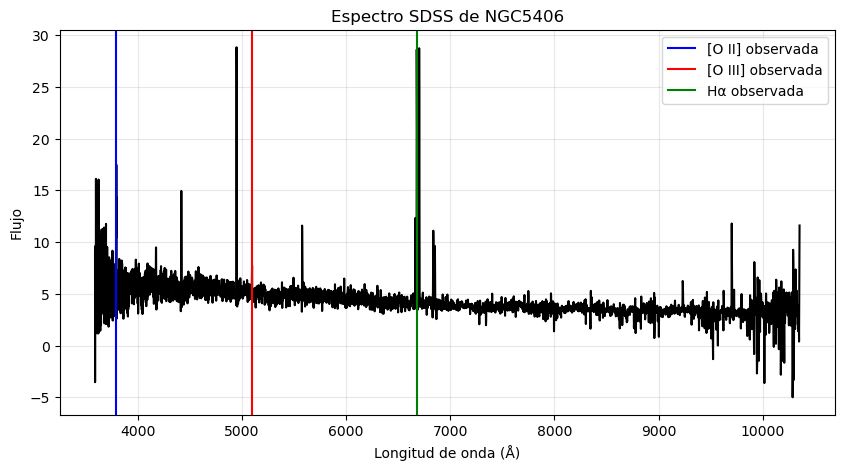

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    10**spectra_data['loglam'],
    spectra_data['flux'],
    color='black'
)

plt.axvline(3793.97, color='blue', label='[O II] observada')
plt.axvline(5096.97, color='red', label='[O III] observada')
plt.axvline(6680.93, color='green', label='Hα observada')

plt.xlabel('Longitud de onda (Å)')
plt.ylabel('Flujo')
plt.title('Espectro SDSS de NGC5406')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Respuesta
</h3>

<p>
NGC 5406 presenta tres líneas de emisión identificadas en el espectro: <b>[O II]</b>, <b>[O III]</b> y <b>Hα</b>.
</p>

<p>
Al comparar sus longitudes de onda observadas con las longitudes de onda en reposo, se obtiene un corrimiento al rojo promedio de:
</p>

$$
z \approx 0.018
$$

<p>
Este resultado indica que la galaxia se está alejando de nosotros y que es relativamente cercana en términos cosmológicos.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Ejercicio 2
</h3>

<p>
Descargue las imágenes FITS en los filtros <code>u</code>, <code>g</code>, <code>r</code>, <code>z</code>, <code>i</code> para <b>NGC 5406</b>.
</p>

<p>
Grafique en cinco paneles diferentes el logaritmo del flujo en cada una de las bandas, recortando siempre alrededor de la galaxia.
</p>

<p>
¿Por qué las imágenes se ven diferentes?
</p>

</div>

In [28]:
from astroquery.sdss import SDSS
import matplotlib.pyplot as plt
import numpy as np

bandas = ['u', 'g', 'r', 'i', 'z']

imagenes = {}

for banda in bandas:
    img = SDSS.get_images(matches=xid, band=banda)
    imagenes[banda] = img[0][0].data

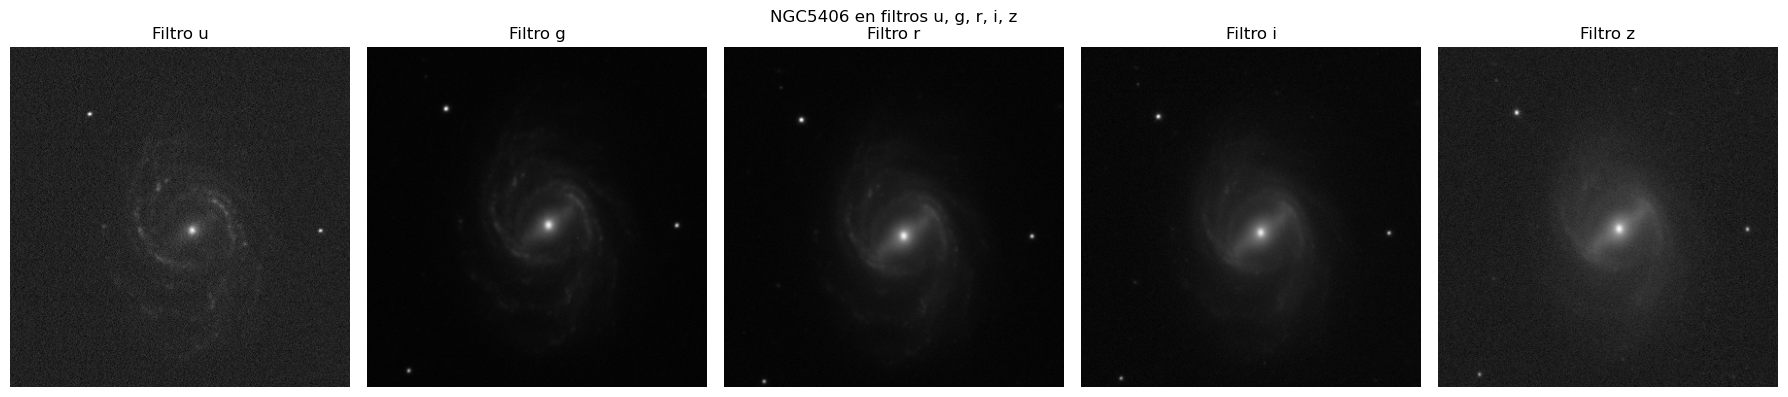

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, banda in zip(axes, bandas):
    
    data = imagenes[banda]
    
    # Recorte alrededor de la galaxia
    recorte = data[125:475, 750:1100]
    
    # Para evitar problemas con valores negativos o cero
    recorte_log = np.log10(recorte - np.min(recorte) + 1)
    
    ax.imshow(recorte_log, origin='lower', cmap='gray')
    ax.set_title(f'Filtro {banda}')
    ax.axis('off')

plt.suptitle('NGC5406 en filtros u, g, r, i, z')
plt.tight_layout()
plt.show()

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Respuesta
</h3>

<p>
Las imágenes se ven diferentes porque cada filtro observa una parte distinta del espectro electromagnético.
</p>

<p>
El filtro <code>u</code> resalta estrellas jóvenes y calientes, mientras que <code>g</code> y <code>r</code> muestran principalmente la población estelar visible.
</p>

<p>
Los filtros <code>i</code> y <code>z</code> observan longitudes de onda más rojas, donde predominan estrellas más viejas y frías.
</p>

<p>
Por eso cambian el brillo del núcleo, la visibilidad de los brazos espirales y la distribución de la luz de la galaxia.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Ejercicio 3
</h3>

<p>
Calcule el perfil radial de flujo de <b>NGC 5406</b>.
</p>

<p>
Para ello, tome 10 líneas diferentes que comiencen desde el centro de la galaxia y grafique el flujo como función del radio para esas diez líneas.
</p>

<p>
¿Qué tipo de función debería ajustar sus resultados?
</p>

</div>

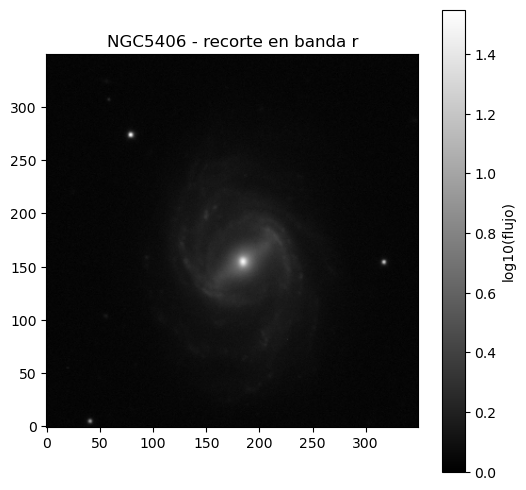

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Usamos la imagen en banda r
data = imagenes['r']

# Recorte alrededor de la galaxia, igual que en el ejercicio 2
recorte = data[125:475, 750:1100]

# Mostrar el recorte para ubicar el centro
plt.figure(figsize=(6,6))
plt.imshow(np.log10(recorte - np.min(recorte) + 1), origin='lower', cmap='gray')
plt.title('NGC5406 - recorte en banda r')
plt.colorbar(label='log10(flujo)')
plt.show()

In [31]:
# Centro aproximado de la galaxia dentro del recorte
y0, x0 = np.array(recorte.shape) // 2

print("Centro aproximado:", x0, y0)

Centro aproximado: 175 175


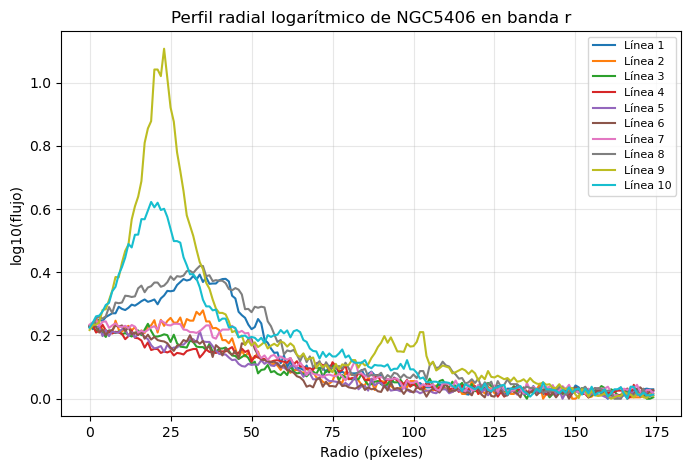

In [33]:
plt.figure(figsize=(8,5))

for i, theta in enumerate(angulos):
    
    r = np.arange(0, radio_max)
    
    x = (x0 + r*np.cos(theta)).astype(int)
    y = (y0 + r*np.sin(theta)).astype(int)
    
    flujo = recorte[y, x]
    flujo_log = np.log10(flujo - np.min(flujo) + 1)
    
    plt.plot(r, flujo_log, label=f'Línea {i+1}')

plt.xlabel('Radio (píxeles)')
plt.ylabel('log10(flujo)')
plt.title('Perfil radial logarítmico de NGC5406 en banda r')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Respuesta
</h3>

<p>
El flujo disminuye con el radio, indicando que la galaxia es más brillante en su región central y más tenue hacia sus bordes.
</p>

<p>
La forma general de las curvas sugiere un comportamiento aproximadamente exponencial, característico de los discos de galaxias espirales.
</p>

<p>
Las desviaciones observadas pueden atribuirse a la presencia de brazos espirales y regiones de formación estelar.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Ejercicio 4
</h3>

<p>
Repita el mismo procedimiento realizado en este notebook, incluyendo los ejercicios 2 y 3, para la galaxia <b>SDSS J013755.71+010004.9</b>.
</p>

<p>
¿Por qué esta galaxia se ve tan diferente de <b>NGC 5406</b>?
</p>

</div>

In [62]:
images = SDSS.get_images(
    run=int(obj['run']),
    rerun=int(obj['rerun']),
    camcol=int(obj['camcol']),
    field=int(obj['field']),
    band='g'
)

img = images[0][0].data

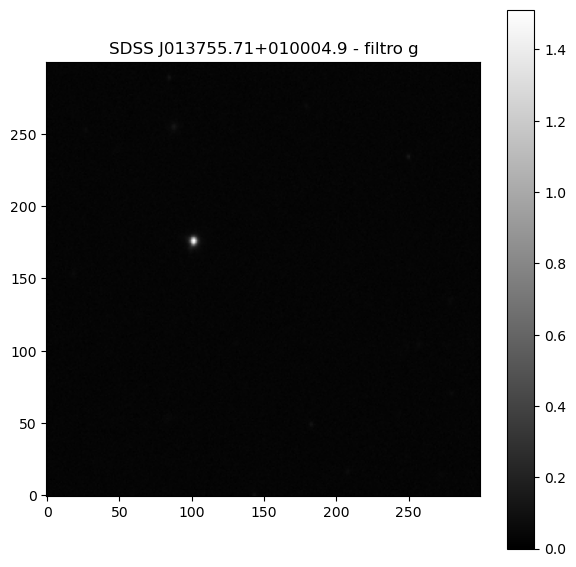

In [63]:
centro_y = img.shape[0] // 2
centro_x = img.shape[1] // 2

recorte = img[centro_y-150:centro_y+150, centro_x-150:centro_x+150]

plt.figure(figsize=(7,7))
plt.imshow(
    np.log10(recorte - np.min(recorte) + 1),
    origin='lower',
    cmap='gray'
)
plt.colorbar()
plt.title('SDSS J013755.71+010004.9 - filtro g')
plt.show()

In [65]:
bandas = ['u', 'g', 'r', 'i', 'z']
imagenes_j013755 = {}

for banda in bandas:

    images = SDSS.get_images(
        run=int(obj['run']),
        rerun=int(obj['rerun']),
        camcol=int(obj['camcol']),
        field=int(obj['field']),
        band=banda
    )

    imagenes_j013755[banda] = images[0][0].data

print("Imágenes descargadas")

Imágenes descargadas


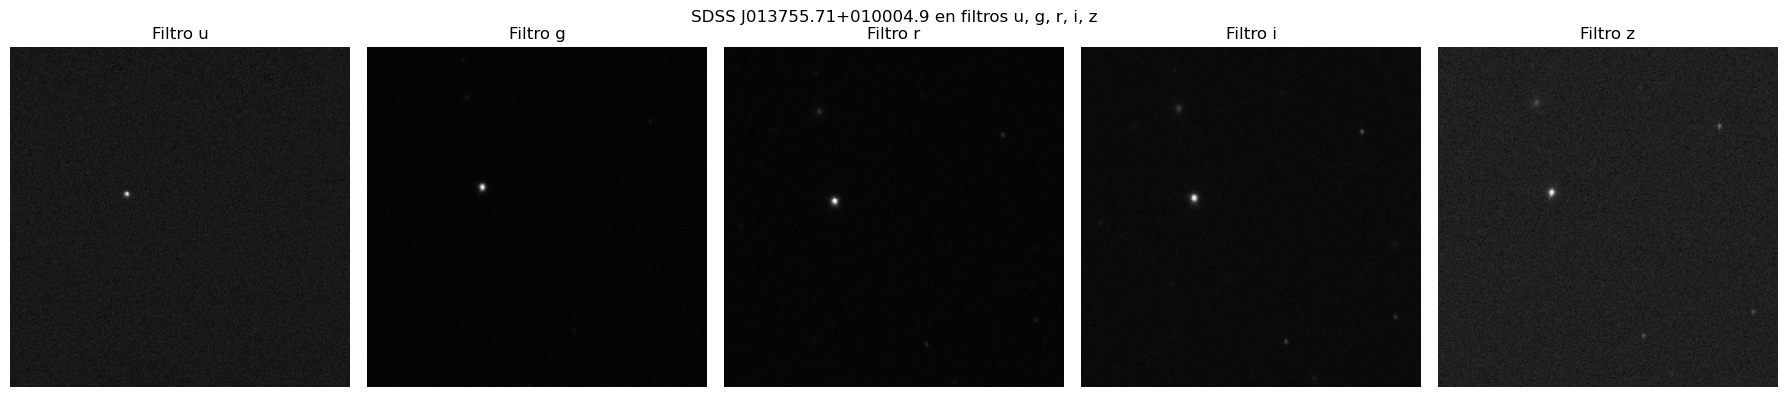

In [66]:
fig, axes = plt.subplots(1, 5, figsize=(18,4))

for ax, banda in zip(axes, bandas):
    data = imagenes_j013755[banda]

    centro_y = data.shape[0] // 2
    centro_x = data.shape[1] // 2

    recorte = data[centro_y-150:centro_y+150, centro_x-150:centro_x+150]
    recorte_log = np.log10(recorte - np.min(recorte) + 1)

    ax.imshow(recorte_log, origin='lower', cmap='gray')
    ax.set_title(f'Filtro {banda}')
    ax.axis('off')

plt.suptitle('SDSS J013755.71+010004.9 en filtros u, g, r, i, z')
plt.tight_layout()
plt.show()

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Respuesta
</h3>

<p>
La galaxia <b>SDSS J013755.71+010004.9</b> se ve muy diferente de <b>NGC 5406</b> porque aparece mucho más compacta y débil en las imágenes.
</p>

<p>
Mientras NGC 5406 muestra una estructura espiral extendida, con brazos claramente visibles, esta galaxia se observa casi como una fuente puntual o poco resuelta.
</p>

<p>
Esto puede deberse a que está más lejana, tiene menor tamaño aparente o posee una morfología más compacta. Por eso, en los filtros <code>u</code>, <code>g</code>, <code>r</code>, <code>i</code> y <code>z</code>, no se distinguen brazos espirales ni un disco amplio como en NGC 5406.
</p>

<p>
Además, al ser más débil, el ruido de fondo afecta más la imagen, especialmente en los filtros <code>u</code> y <code>z</code>.
</p>

</div>